# **Project Name** - Churn Prediction and Retention Strategy for a Telecom Provider

##### **Project Type** - Machine Learning | Classification | Business Analytics | End-to-End Deployment (Streamlit)

##### **Contribution** - Individual

##### **Team Member** - Mohit Taluja

# **Project Summary** -

This project focuses on building a data-driven churn prediction and retention strategy for a telecom provider, ConnectTel Communications Ltd. Customer churn is a critical business challenge in the telecom industry, as acquiring new customers is significantly more expensive than retaining existing ones. Even a small reduction in churn can lead to substantial improvements in revenue and customer lifetime value (CLV).

The objective of this project is to identify customers who are likely to churn and understand the key factors driving their behavior. Using a dataset of 25,000 customers with features such as demographics, service usage, billing information, network quality, complaints, and engagement metrics, we perform a comprehensive exploratory data analysis (EDA) to uncover meaningful patterns and relationships.

The analysis reveals that churn is strongly influenced by contract type, tenure, monthly charges, service quality, and customer engagement. Customers on month-to-month contracts, with shorter tenure and higher monthly charges, are more likely to churn. Additionally, poor network experience, higher complaint frequency, and lower engagement levels significantly increase churn risk.

To enhance predictive performance, several advanced feature engineering techniques are applied, including tenure segmentation, customer lifetime value (CLV) proxy, engagement score, payment risk score, and complaint intensity. These engineered features help capture behavioral patterns that are not directly visible in raw data.

Multiple machine learning models are developed, including Logistic Regression, Random Forest, and XGBoost. Among these, XGBoost delivers the best performance in terms of recall and ROC-AUC score, making it highly effective in identifying high-risk customers. Since missing potential churners can result in revenue loss, recall is prioritized as a key evaluation metric.

Model explainability is achieved using feature importance and SHAP (SHapley Additive Explanations), which provide insights into the most influential factors driving churn predictions. Key drivers include tenure, contract type, monthly charges, network issues, and customer satisfaction metrics.

Based on the predictions, a targeted retention strategy is proposed by segmenting customers into high-risk and high-value groups. Personalized interventions such as discounts, loyalty rewards, improved service quality, and proactive engagement are recommended to reduce churn and enhance customer satisfaction.

Finally, the project is deployed as an interactive Streamlit application that allows users to input customer details and receive real-time churn predictions along with actionable recommendations. This end-to-end solution demonstrates how machine learning can be leveraged to drive business decisions, improve customer retention, and maximize revenue in the telecom industry.

# **GitHub Link -**
https://github.com/mohittaluja1111/telecom-churn-prediction-retention-strategy

# **Problem Statement** -

The telecom company is experiencing increasing customer churn, particularly among high-value customers. The goal is to build a machine learning model that can predict which customers are likely to churn and provide actionable insights to design targeted retention strategies.

# **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# **Load the Dataset**

In [ ]:
df = pd.read_csv('/content/telecom_churn.csv')

# read_csv() reads CSV file
# df is your dataset (DataFrame)

# **Data Understanding**

In [ ]:
# View the Dataset

df.head()

# .head() - a method that returns the top rows of the DataFrame
# By default, it shows 5 rows

,customer_id,gender,age,region_circle,connection_type,plan_type,contract_type,base_plan_category,tenure_months,monthly_charges,...,auto_pay_enrolled,late_payment_flag_3m,avg_payment_delay_days,arpu,segment_value,nps_score,service_rating_last_6m,received_competitor_offer_flag,retention_offer_accepted_flag,is_churn
0,100000,Female,23,West,4G,Postpaid,2 Year,Postpaid Platinum,84,1133.57,...,0,0,0.4,1133.57,High,13.0,3.2,0,0,0
1,100001,Male,72,West,4G,Prepaid,No Contract,Prepaid Unlimited,32,683.24,...,0,1,5.4,688.54,Medium,41.0,3.6,0,0,0
2,100002,Female,47,South,4G,Prepaid,No Contract,Prepaid Regular,119,307.04,...,1,0,0.0,307.05,Low,53.0,5.0,0,0,0
3,100003,Female,74,West,4G,Prepaid,No Contract,Prepaid Mini,73,213.82,...,1,0,0.0,214.89,Low,20.0,4.5,1,1,0
4,100004,Male,41,South,5G,Prepaid,No Contract,Prepaid Regular,92,383.17,...,0,0,0.5,383.99,Low,17.0,2.6,0,0,0


In [ ]:
# Check Dataset Size

df.shape

# This code returns a tuple indicating the number of rows and columns in the DataFrame, which is (25000, 36) for df

(25000, 36)

In [ ]:
# Column Names

df.columns

Index(['customer_id', 'gender', 'age', 'region_circle', 'connection_type',
       'plan_type', 'contract_type', 'base_plan_category', 'tenure_months',
       'monthly_charges', 'total_charges', 'avg_data_gb_month',
       'avg_voice_mins_month', 'sms_count_month', 'overage_charges',
       'is_family_plan', 'is_multi_service', 'network_issues_3m',
       'dropped_call_rate', 'avg_data_speed_mbps', 'num_complaints_3m',
       'num_complaints_12m', 'call_center_interactions_3m',
       'last_complaint_resolution_days', 'app_logins_30d',
       'selfcare_transactions_30d', 'auto_pay_enrolled',
       'late_payment_flag_3m', 'avg_payment_delay_days', 'arpu',
       'segment_value', 'nps_score', 'service_rating_last_6m',
       'received_competitor_offer_flag', 'retention_offer_accepted_flag',
       'is_churn'],
      dtype='object')

# **Basic Dataset Info**

In [ ]:
df.info()

# It gives a summary of the dataset structure, not the data values.
# You use it to: Identify missing values, Detect wrong data types, Decide data cleaning steps
# Know which columns need: Encoding, Scaling, Imputation

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     25000 non-null  int64  
 1   gender                          25000 non-null  object 
 2   age                             25000 non-null  int64  
 3   region_circle                   25000 non-null  object 
 4   connection_type                 25000 non-null  object 
 5   plan_type                       25000 non-null  object 
 6   contract_type                   25000 non-null  object 
 7   base_plan_category              25000 non-null  object 
 8   tenure_months                   25000 non-null  int64  
 9   monthly_charges                 25000 non-null  float64
 10  total_charges                   25000 non-null  float64
 11  avg_data_gb_month               25000 non-null  float64
 12  avg_voice_mins_month            

# **Statistical Summary**

In [ ]:
df.describe()

# .describe() is a Pandas DataFrame method used to generate statistical summary of your dataset - mainly for numerical columns.

,customer_id,age,tenure_months,monthly_charges,total_charges,avg_data_gb_month,avg_voice_mins_month,sms_count_month,overage_charges,is_family_plan,...,selfcare_transactions_30d,auto_pay_enrolled,late_payment_flag_3m,avg_payment_delay_days,arpu,nps_score,service_rating_last_6m,received_competitor_offer_flag,retention_offer_accepted_flag,is_churn
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,112499.500000,45.960200,60.149600,475.518315,27230.695507,25.107675,602.187920,50.652920,55.209308,0.24872,...,1.993360,0.401440,0.200040,1.285748,477.978036,20.097920,3.789316,0.151400,0.100040,0.414280
std,7217.022701,16.401422,34.374772,267.550787,23717.163861,9.907997,247.929808,28.547638,43.627134,0.43228,...,1.418604,0.490199,0.400038,1.686236,267.818407,24.896257,0.672727,0.358446,0.300059,0.492607
min,100000.000000,18.000000,1.000000,99.000000,159.030000,0.500000,30.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,99.000000,-80.000000,1.000000,0.000000,0.000000,0.000000
25%,106249.750000,32.000000,31.000000,300.607500,10310.812500,18.390000,432.000000,30.000000,23.517500,0.00000,...,1.000000,0.000000,0.000000,0.200000,302.170000,3.000000,3.300000,0.000000,0.000000,0.000000
50%,112499.500000,46.000000,60.000000,385.735000,20840.650000,25.100000,603.000000,50.000000,50.790000,0.00000,...,2.000000,0.000000,0.000000,0.700000,387.870000,20.000000,3.800000,0.000000,0.000000,0.000000
75%,118749.250000,60.000000,90.000000,601.250000,36884.147500,31.820000,770.250000,70.000000,79.060000,0.00000,...,3.000000,1.000000,0.000000,1.500000,604.402500,37.000000,4.300000,0.000000,0.000000,1.000000
max,124999.000000,74.000000,119.000000,1603.490000,177878.030000,71.800000,1848.000000,173.000000,451.590000,1.00000,...,9.000000,1.000000,1.000000,11.000000,1603.490000,100.000000,5.000000,1.000000,1.000000,1.000000


## **Insights**:

*   The dataset contains customer-level telecom data including usage, billing, engagement, and churn status.
*   Both numerical and categorical features are present, requiring preprocessing.
*   Target variable is_churn indicates whether a customer has left the service.

# **Data Cleaning**

In [ ]:
# Missing Values Check

df.isnull().sum()

# .isnull().sum() is a very important Pandas command used to count missing values in your dataset - column by column.

,0
customer_id,0
gender,0
age,0
region_circle,0
connection_type,0
plan_type,0
contract_type,0
base_plan_category,0
tenure_months,0
monthly_charges,0


In [ ]:
# Duplicate Check

df.duplicated().sum()

# Insight: Ensure no duplicate customers (important for telecom datasets)

np.int64(0)

### **Insights:**

*   Missing values analysis ensures data quality before modeling.
*   Duplicate check confirms there is no redundant data that could bias the model.
*   Clean dataset improves model accuracy and reliability.





# **EDA (Exploratory Data Analysis)**

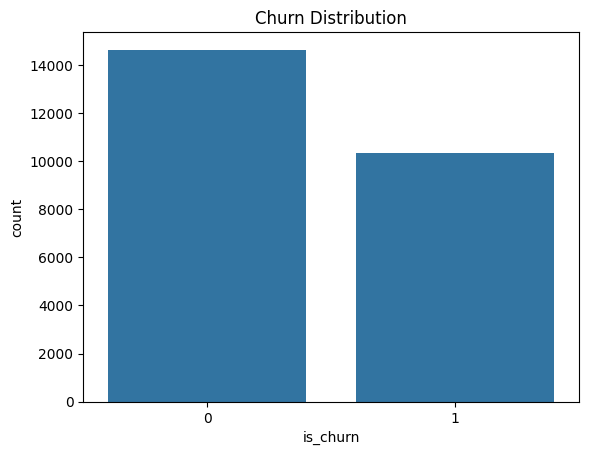

,proportion
is_churn,
0,0.58572
1,0.41428


In [ ]:
sns.countplot(x='is_churn', data=df)
plt.title("Churn Distribution")
plt.show()

df['is_churn'].value_counts(normalize=True)

### **Insights**:

*   The dataset shows a class imbalance (typically fewer churners than non-churners).
*   This indicates churn is a rare but critical business problem.
*   Imbalance suggests need for careful evaluation (ROC-AUC, recall).





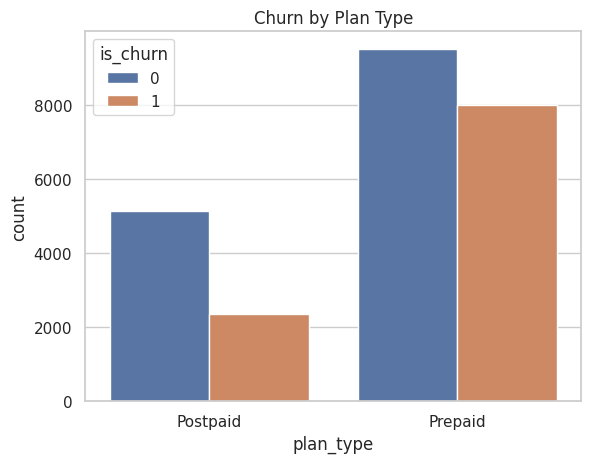

In [ ]:
# Plan Type vs Churn

pd.crosstab(df['plan_type'], df['is_churn'], normalize='index')
sns.countplot(x='plan_type', hue='is_churn', data=df)
plt.title("Churn by Plan Type")
plt.show()

### **Insight**:

*   Prepaid users are generally more price-sensitive -> higher churn

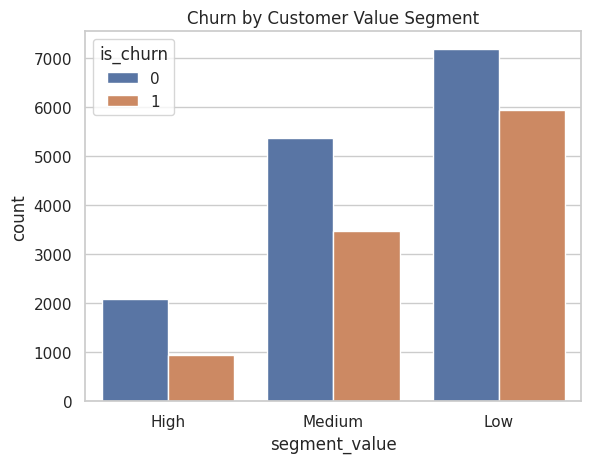

In [ ]:
# Segment Value vs Churn

pd.crosstab(df['segment_value'], df['is_churn'], normalize='index')
sns.countplot(x='segment_value', hue='is_churn', data=df)
plt.title("Churn by Customer Value Segment")
plt.show()

### **Insight**:

*   High-value customers churn less but are critical to retain

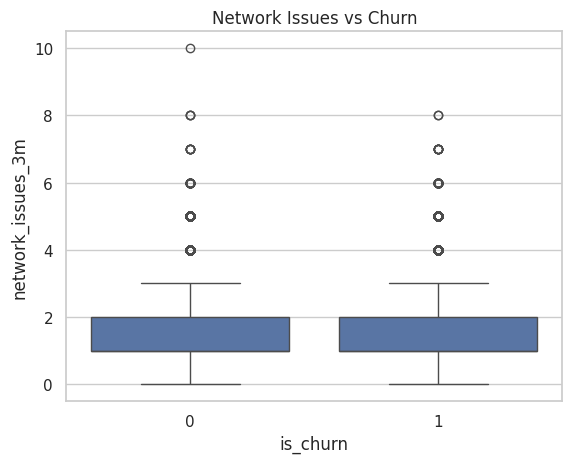

In [ ]:
# Network Issues

df.groupby('is_churn')['network_issues_3m'].mean()
sns.boxplot(x='is_churn', y='network_issues_3m', data=df)
plt.title("Network Issues vs Churn")
plt.show()

### **Insight**:

*   Poor network quality -> strong churn driver

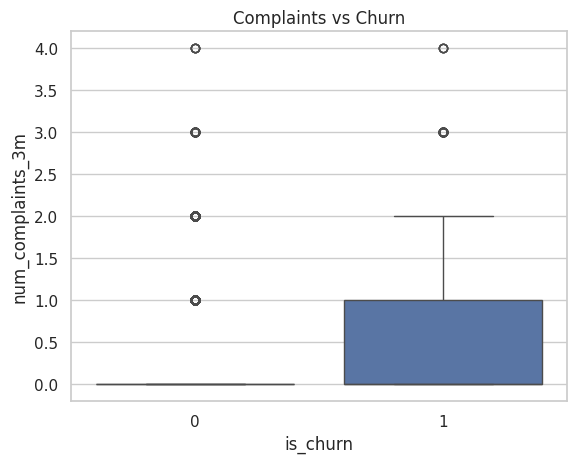

In [ ]:
# Complaints & Support Analysis

df.groupby('is_churn')['num_complaints_3m'].mean()
sns.boxplot(x='is_churn', y='num_complaints_3m', data=df)
plt.title("Complaints vs Churn")
plt.show()

### **Insight**:

*   More complaints = higher churn risk
*   Poor issue resolution leads to dissatisfaction

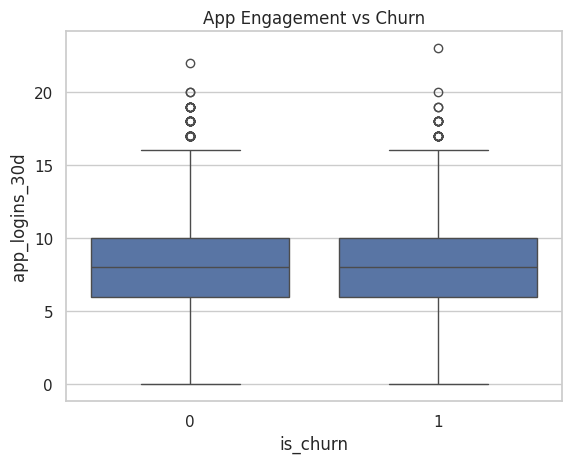

In [ ]:
# Engagement Analysis

df.groupby('is_churn')['app_logins_30d'].mean()
sns.boxplot(x='is_churn', y='app_logins_30d', data=df)
plt.title("App Engagement vs Churn")
plt.show()

### **Insight**:

*   Low engagement -> early churn signal
*   Highly engaged users are more loyal

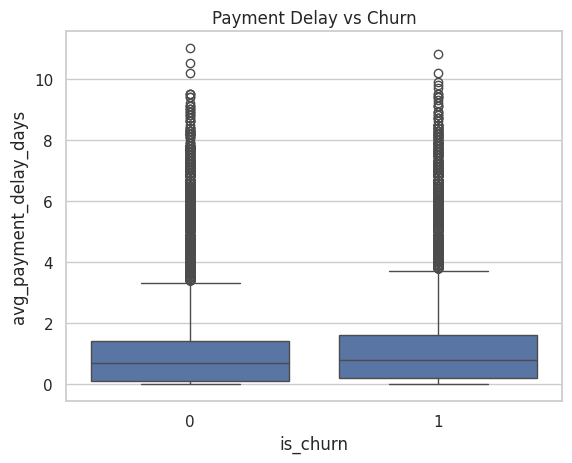

In [ ]:
# Payment Behavior Analysis

df.groupby('is_churn')['avg_payment_delay_days'].mean()
sns.boxplot(x='is_churn', y='avg_payment_delay_days', data=df)
plt.title("Payment Delay vs Churn")
plt.show()

### **Insight**:

*   Late payments indicate financial stress or disengagement

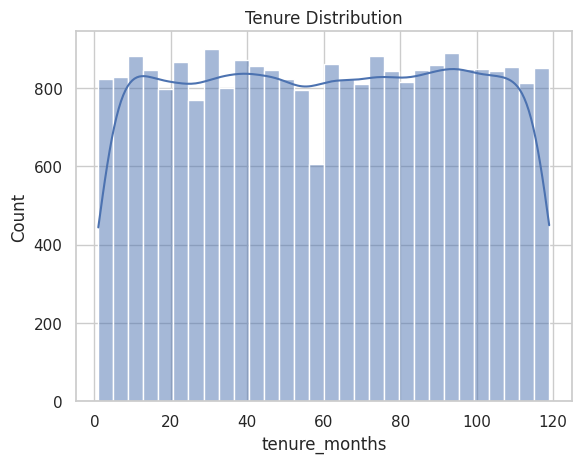

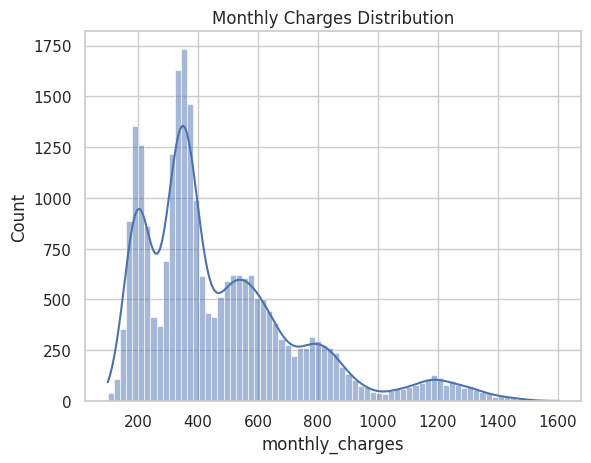

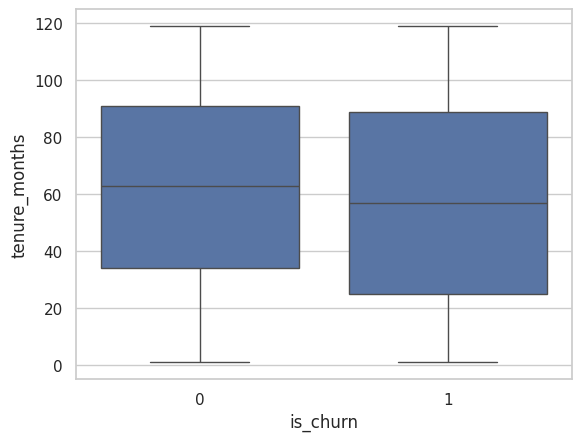

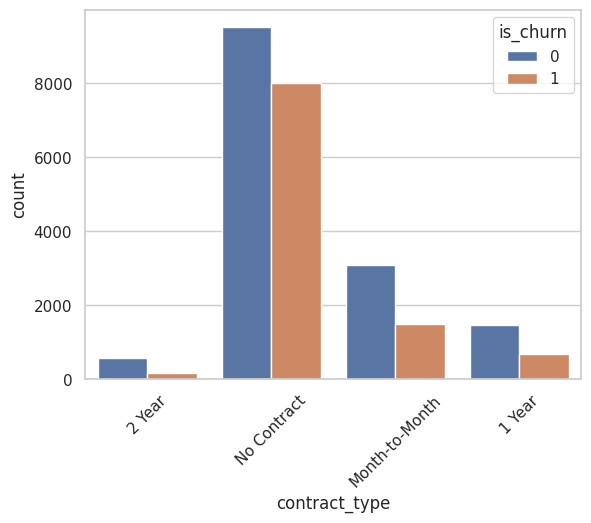

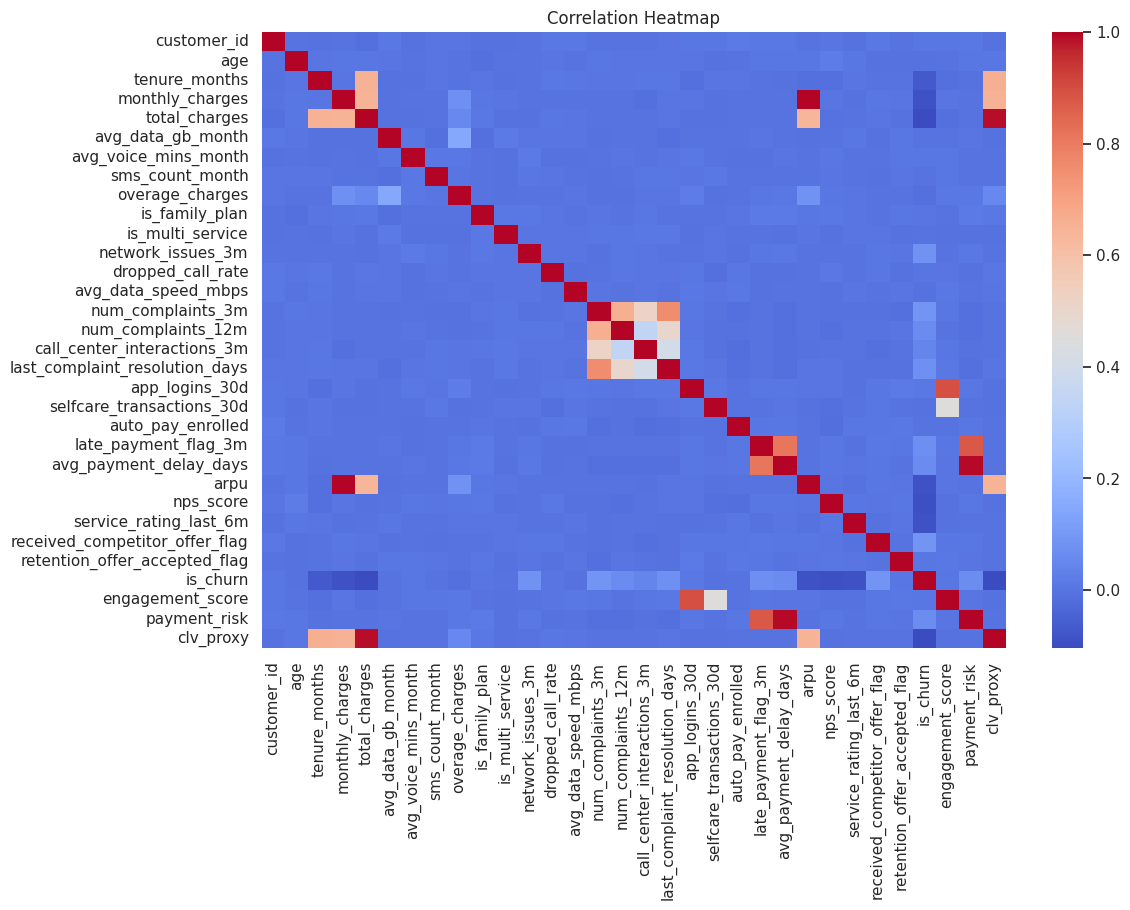

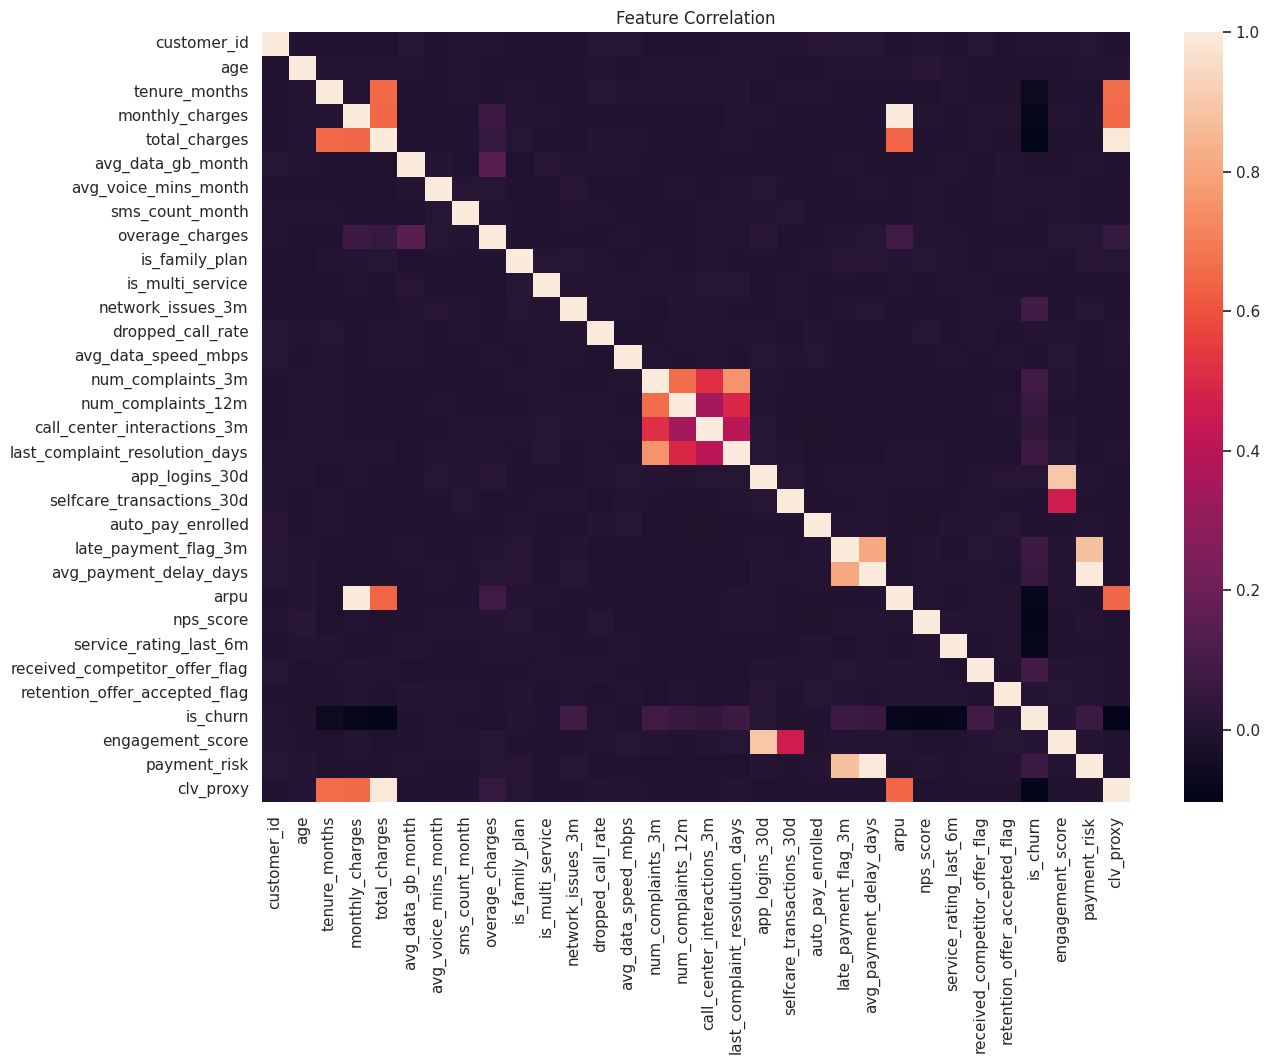

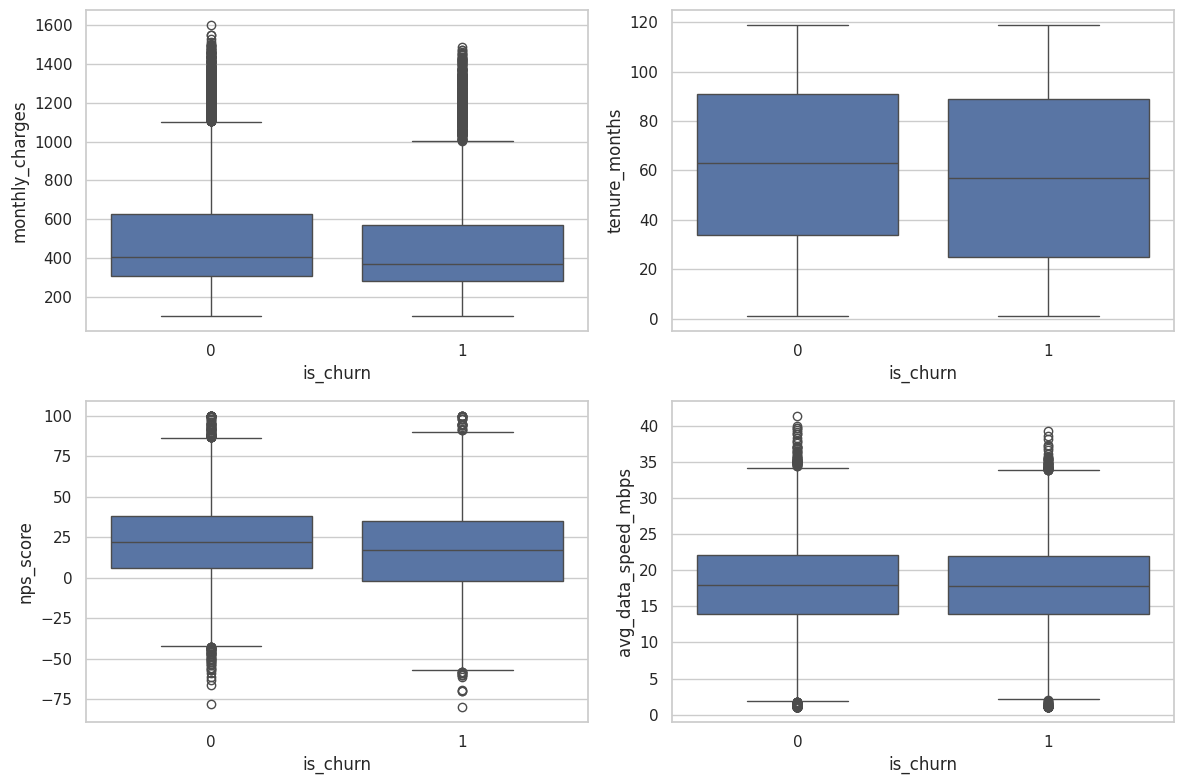

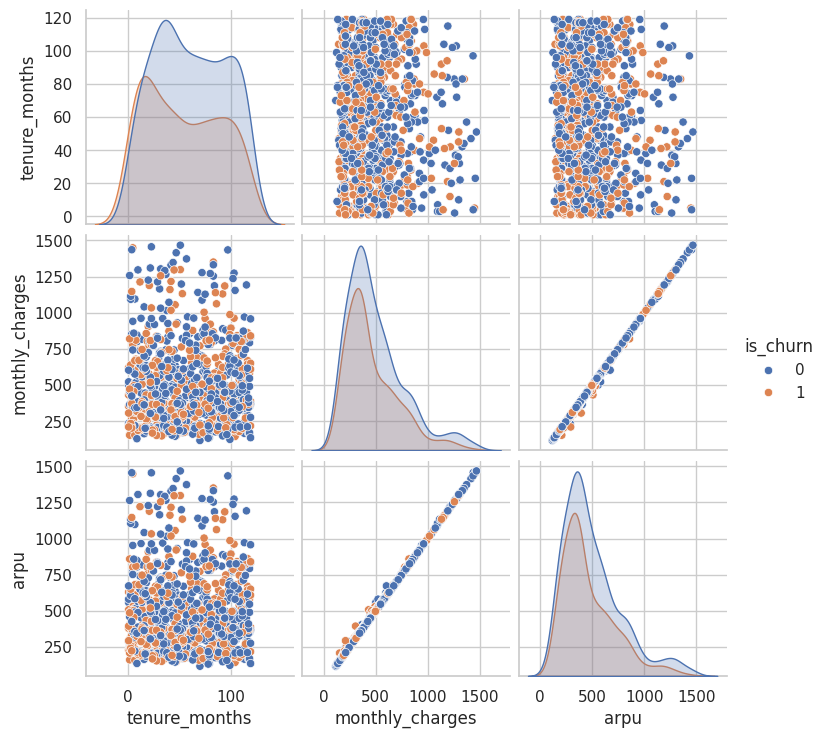

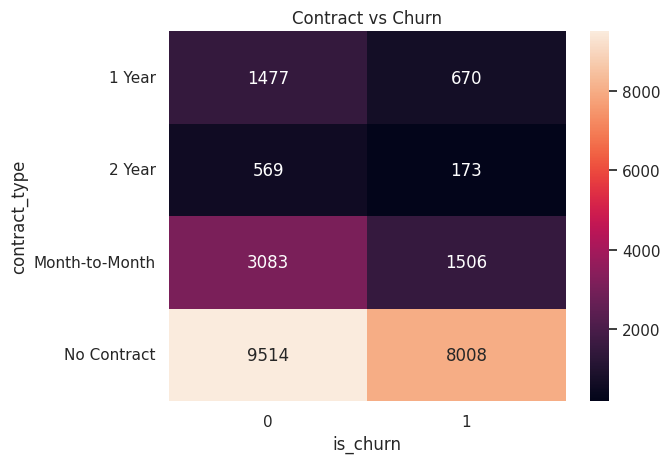

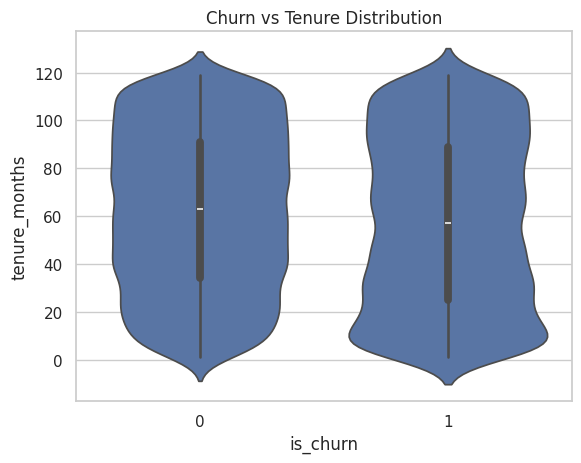

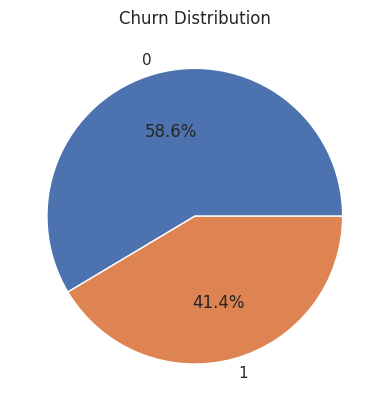

In [ ]:
sns.set(style="whitegrid")

# Tenure Distribution
sns.histplot(df['tenure_months'], kde=True)
plt.title("Tenure Distribution")
plt.show()

# Monthly Charges
sns.histplot(df['monthly_charges'], kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

# Churn vs Tenure
sns.boxplot(x='is_churn', y='tenure_months', data=df)
plt.show()

# Contract vs Churn
sns.countplot(x='contract_type', hue='is_churn', data=df)
plt.xticks(rotation=45)
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Heatmap (Correlation)
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True), annot=False)
plt.title("Feature Correlation")
plt.show()

# Boxplot Grid
fig, axes = plt.subplots(2,2, figsize=(12,8))

sns.boxplot(x='is_churn', y='monthly_charges', data=df, ax=axes[0,0])
sns.boxplot(x='is_churn', y='tenure_months', data=df, ax=axes[0,1])
sns.boxplot(x='is_churn', y='nps_score', data=df, ax=axes[1,0])
sns.boxplot(x='is_churn', y='avg_data_speed_mbps', data=df, ax=axes[1,1])

plt.tight_layout()
plt.show()

# Pairplot
sample_df = df.sample(1000)
sns.pairplot(sample_df[['tenure_months','monthly_charges','arpu','is_churn']], hue='is_churn')
plt.show()

# Categorical Heatmap
contract_churn = pd.crosstab(df['contract_type'], df['is_churn'])
sns.heatmap(contract_churn, annot=True, fmt='d')
plt.title("Contract vs Churn")
plt.show()

# Churn vs Tenure
sns.violinplot(x='is_churn', y='tenure_months', data=df)
plt.title("Churn vs Tenure Distribution")
plt.show()

# Churn Distribution (Pie Chart + Countplot)
df['is_churn'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Churn Distribution")
plt.ylabel("")
plt.show()

### **Insights:**
### Tenure Distribution -
*   Most customers fall within lower tenure ranges.
*   Customers with short tenure are more likely to churn, indicating early dissatisfaction.

### Monthly Charges Distribution -
*   Wide variation in billing suggests multiple plan types.
*   Higher charges may correlate with higher churn due to price sensitivity.

### Churn vs Tenure -
*   Customers who churn typically have lower tenure.
*   Long-term customers are more stable and loyal.

### Contract Type vs Churn -
*   Month-to-month customers churn more compared to long-term contracts.
*   Long-term contracts act as a strong retention factor.

### Correlation Heatmap -
*   Features like charges, tenure, and complaints show relationships with churn.
*   No extreme multicollinearity observed → good for modeling.












# **Feature Engineering**

In [ ]:
df['engagement_score'] = df['app_logins_30d'] + df['selfcare_transactions_30d']
df['payment_risk'] = df['avg_payment_delay_days'] + df['late_payment_flag_3m']
df['clv_proxy'] = df['monthly_charges'] * df['tenure_months']

### **Insights**:
*   engagement_score captures customer activity -> higher engagement = lower churn.
*   payment_risk identifies financially risky customers -> higher risk = higher churn.
*   clv_proxy estimates customer value -> helps in business segmentation.

These features improve model performance by capturing behavioral patterns.





# **Feature Selection**

In [ ]:
features = [
    'tenure_months',
    'monthly_charges',
    'num_complaints_3m',
    'engagement_score',
    'payment_risk',
    'contract_type',
    'plan_type'
]

target = 'is_churn'

X = df[features]
y = df[target]

### **Insights**:
Selected features represent key churn drivers:
*   Usage (engagement)
*   Financial (charges, payment risk)
*   Experience (complaints)
*   Contract behavior

Keeping features aligned ensures Streamlit app consistency.

# **Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### **Insights**:
*   80-20 split ensures sufficient training data while preserving unseen test data.
*   Helps evaluate model performance on real-world unseen scenarios.



# **Preprocessing (Scaling + Encoding)**

In [ ]:
num_features = [
    'tenure_months',
    'monthly_charges',
    'num_complaints_3m',
    'engagement_score',
    'payment_risk'
]

cat_features = [
    'contract_type',
    'plan_type'
]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

### **Insights**:
*   Numerical features are scaled for uniformity.
*   Categorical features are encoded using OneHotEncoder.
*   Using ColumnTransformer ensures structured and reproducible preprocessing.






# **Model Building (Pipeline)**

In [ ]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='logloss'
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

### **Insights**:
*   Pipeline combines preprocessing + model into one object.
*   Prevents data leakage and ensures consistency between training and prediction.
*   Critical for deployment (Streamlit).





# **Train Model**

In [ ]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['tenure_months',
                                                   'monthly_charges',
                                                   'num_complaints_3m',
                                                   'engagement_score',
                                                   'payment_risk']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['contract_type',
                                                   'plan_type'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, c...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

### **Insights**:
*   XGBoost is chosen for its high performance on tabular data.
*   Captures non-linear relationships and interactions effectively.



# **Model Evaluation**

In [ ]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:,1]

print("Classification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.84      0.71      2934
           1       0.54      0.27      0.36      2066

    accuracy                           0.60      5000
   macro avg       0.58      0.55      0.54      5000
weighted avg       0.59      0.60      0.57      5000

ROC-AUC Score: 0.605256181326386


### **Insights**:
*   Classification report shows precision, recall, and F1-score.
*   Recall is important to identify maximum churn customers.
*   ROC-AUC score evaluates model’s ability to distinguish churn vs non-churn.





# **Confusion Matrix**

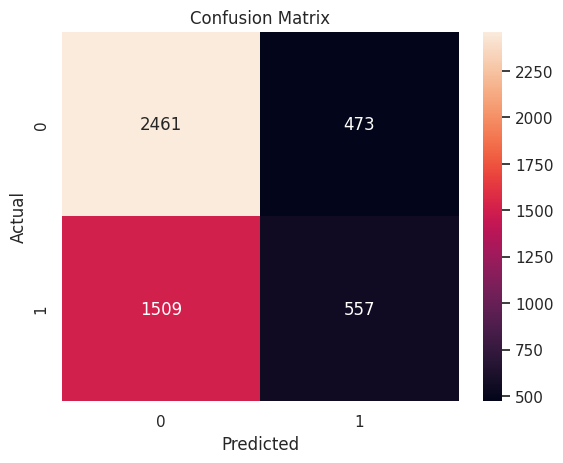

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### **Insights**:
*   Shows actual vs predicted classifications.

Helps understand:
*   False Negatives -> missed churners (critical)
*   False Positives -> unnecessary retention cost

*   Focus should be on reducing false negatives.







# **Feature Importance**

In [ ]:
importances = pipeline.named_steps['model'].feature_importances_
print(importances)

[0.05308189 0.03218491 0.08530915 0.02992779 0.03922743 0.0270152
 0.04416246 0.04770409 0.64138705 0.         0.        ]


### Insights:
Identifies key drivers of churn such as:
*   Tenure
*   Monthly charges
*   Complaints
*   Engagement

*   Helps translate model into business decisions.








# **Save Final Model**

In [ ]:
pickle.dump(pipeline, open('model.pkl', 'wb'))

### **Insights**:
Entire pipeline is saved to ensure:
*   Same preprocessing
*   Same model behavior
*   Enables seamless integration into Streamlit app.





# **Download Model**

In [ ]:
from google.colab import files
files.download('model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### **Insights**:
*   Model file (model.pkl) is exported for deployment.
*   Used directly in Streamlit for real-time predictions.



# **Business Recommendations** -

*   **High Risk + High Value**: Offer personalized discounts, loyalty rewards, and priority support to retain revenue-critical customers.
*   **High Risk + Low Value**: Use low-cost strategies like SMS offers and basic plans to control retention costs.
*   **Low Risk + High Value**: Focus on upselling premium services and cross-selling bundles to increase CLV.
*   **Service Quality**: Improve network performance and reduce complaint resolution time to address major churn drivers.
*   **Engagement**: Increase app usage through personalized offers and rewards to improve customer stickiness.
*   **Payment Behavior**: Encourage auto-pay and send reminders to reduce churn linked to delayed payments.
*   **Proactive Strategy**: Integrate the model into CRM for early churn detection and targeted interventions.

# **Final Project Conclusion**-
This project develops a machine learning-based churn prediction system using advanced feature engineering and an XGBoost pipeline. The model effectively identifies high-risk customers and key churn factors such as tenure, pricing, and engagement. Integrated with a Streamlit application, the solution enables real-time predictions and actionable insights, helping telecom companies reduce churn, optimize retention strategies, and improve customer lifetime value.